Topic: What Drives Mortgage Costs in Spain?
An Analysis of Loan Conditions and Their Impact on APR

Problem Statement: 
Mortgage costs in Spain vary significantly depending on customer profile, loan conditions, and bank strategy.
This project aims to analyze which loan conditions most strongly impact the Annual Percentage Rate (APR).

Current Research: explanations of different components of APR (interest rate type, commissions, insurance requirements, and payment frequency) and how they affect it. But no in depth analysis and no quantified analysis. There is no central, public database of Spanish mortgage offers. APIs: There are no open APIs that allow private individuals to retrieve real-time mortgage offer data across banks. Mortgage data remains decentralized and often manually accessible only (tried APIs TrueLayer, Tink - but no access to real data). Consumers typically rely on bank websites, mortgage comparison platforms, financial advisors or brokers.

Features:
- loan type (resident, no-resident) / (variable/fixed/mixed)
- loan amount (kEUR)
- APR (%)
- bonus conditions (boolean)
- loan term (years)
- bank type (traditional / digital)

Base Case
Investment:
- Loan amount: 100 k€ (property price: 150 k€)
- Location: Madrid
- Usage: Primary Residence
- Property type: Second-hand

Applier: 
- Net income: 2 k€/month
- Residency: Spanish resident
- Age: 32 years

Data Structure
- Tbl 1 "Loans": loan simulations as observations 
- Tbl 2 "Banks": banks master

In [ ]:
import pandas as pd
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf 

In [2]:
#import data
df_loans = pd.read_excel("C:\\Users\\Anast\\OneDrive\\Desktop\\Ironhack\\project_1\\mortgage_conditions_spain_v1.xlsx")
df_loans.head()

,Bank_ID,Bank_Type,Bank,Customer_Type,Property_Price,Loan_Amount,Interest_Type,APR,Max_Loan_Term,Bonus_conditions,...,Loan_Term_Group,Scenario_Type,Correlation_Factor_Loan_Term,Correlation_Effect_Loan_Term,ratio_fixed,note,check doubles,Correlation_Factor_Bonus_Condition,Correlation_Effect_Bonus_Condition,Does_Bank_Offer_Bonus_Conditions?
0,2,Traditional,Bankinter,Resident,150000,100000,Mixed,3.84,30,No Bonus,...,Base,Resident Mixed No Bonus Base,-1.000,Decrease,0.5,NaN,BankinterResidentMixedNo Bonus15,0.000000,No Change,0
1,2,Traditional,Bankinter,Resident,150000,100000,Mixed,3.66,30,No Bonus,...,Long-Term,Resident Mixed No Bonus Long-Term,-1.000,Decrease,0.5,NaN,BankinterResidentMixedNo Bonus30,0.000000,No Change,0
2,5,Traditional,Ibercaja,Resident,150000,100000,Fixed,4.09,30,No Bonus,...,Base,Resident Fixed No Bonus Base,-0.618,Decrease,1.0,NaN,IbercajaResidentFixedNo Bonus15,0.545685,Increase,1
3,5,Traditional,Ibercaja,Resident,150000,100000,Fixed,4.26,30,Bonus,...,Base,Resident Fixed Bonus Base,-0.618,Decrease,1.0,NaN,IbercajaResidentFixedBonus15,0.545685,Increase,1
4,5,Traditional,Ibercaja,Resident,150000,100000,Fixed,4.09,30,No Bonus,...,Long-Term,Resident Fixed No Bonus Long-Term,-0.618,Decrease,1.0,NaN,IbercajaResidentFixedNo Bonus25,0.545685,Increase,1


In [3]:
fixed_loans = df_loans[df_loans["Interest_Type"] == "Fixed"]
resident_loans = df_loans[df_loans["Customer_Type"] == "Resident"]
base_case = df_loans[(df_loans["Interest_Type"] == "Fixed")&(df_loans["Customer_Type"] == "Resident")&(df_loans["Loan_Term_Years"] == 15)]

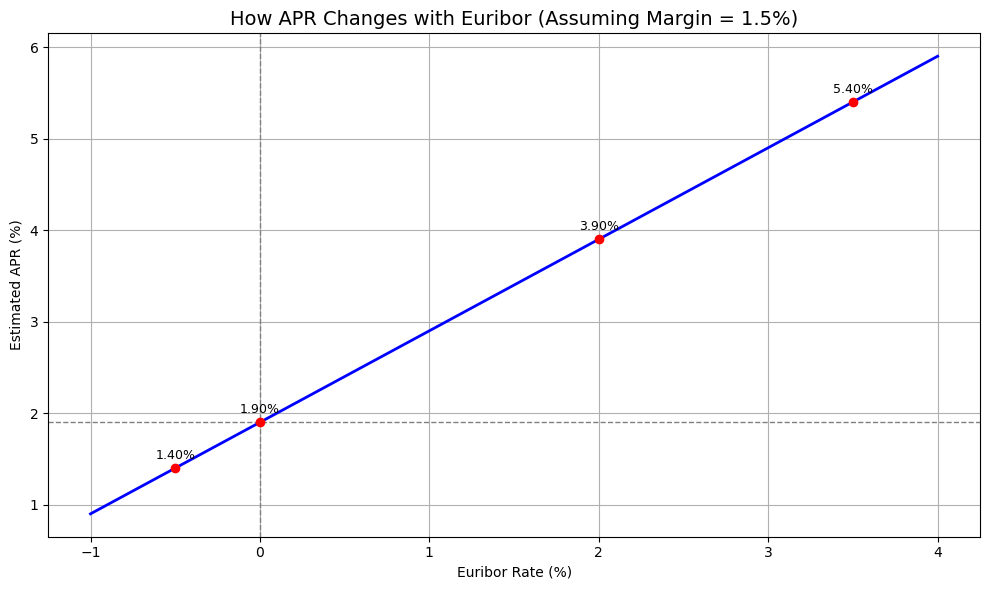

In [ ]:
#APR variable - Simulation and impact from Euribor
#simulate APR depending on Euribor changes
euribor_rates = np.linspace(-1.0, 4.0, 50)  #Euribor from -1% to +4%
bank_margin = 1.5  #example bank margin (constant)
fixed_costs = 0.4  #approximate cost contribution to APR from fees, insurance, etc.

#calculate APR as Euribor + margin + fixed costs
apr_values = euribor_rates + bank_margin + fixed_costs

#plot how APR changes with Euribor"
plt.figure(figsize=(10, 6))
plt.plot(euribor_rates, apr_values, color='blue', linewidth=2)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.axhline(y=bank_margin + fixed_costs, color='gray', linestyle='--', linewidth=1)
plt.title("How APR Changes with Euribor (Assuming Margin = 1.5%)", fontsize=14)
plt.xlabel("Euribor Rate (%)")
plt.ylabel("Estimated APR (%)")
plt.grid(True)
plt.tight_layout()


#annotate example points
for r in [-0.5, 0.0, 2.0, 3.5]:
    apr = r + bank_margin + fixed_costs
    plt.plot(r, apr, 'ro')
    plt.text(r, apr + 0.1, f"{apr:.2f}%", fontsize=9, ha='center')


plt.show()

In [ ]:
#1 test Bonus Conditions
#H0: There is no difference in APR between bonus and no bonus
#H1: Bonus conditions reduce APR
#t-test ind because we want to compare means of 2 independent groups
#we create 2 groups based on bonus conditions
#but first we filter on base case (fixed + 15 years) because we want to compare one type of a loan
fixed_15y = df_loans[(df_loans["Interest_Type"] == "Fixed")&(df_loans["Loan_Term_Years"] == 15)]
group_fix_bonus_15y = fixed_15y[fixed_15y["Bonus_conditions"] == "Bonus"]["APR"].dropna()
group_fix_no_bonus_15y = fixed_15y[fixed_15y["Bonus_conditions"] == "No Bonus"]["APR"].dropna()
#run independent-test
t_test, p_value = ttest_ind(group_fix_bonus_15y, group_fix_no_bonus_15y, equal_var = False)

print("Mean APR without Bonus:", round(group_fix_no_bonus_15y.mean(), 2))
print("Mean APR with Bonus:", round(group_fix_bonus_15y.mean(), 2))
print("P-value: ", round(p_value, 2))
if p_value < 0.05:
    print("Significant: Bonus conditions affect APR.")
else:
    print("Not Significant: No strong evidence that bonus conditions affect APR.")

#The mean APR with bonus is 3.99%, and without bonus is 4.26%. However, the p-value is 0.23, so the difference is not statistically significant at the 95% confidence level. 
#Likely its due to small sample size. so we do the same test but with all observations. However we have the risk then to mix features like loan term and bonus conditions

Mean APR without Bonus: 4.26
Mean APR with Bonus: 3.99
P-value:  0.23
Not Significant: No strong evidence that bonus conditions affect APR.


In [6]:
group_bonus = df_loans[df_loans["Bonus_conditions"] == "Bonus"]["APR"].dropna()
group_no_bonus = df_loans[df_loans["Bonus_conditions"] == "No Bonus"]["APR"].dropna()
t_test, p_value = ttest_ind(group_bonus, group_no_bonus, equal_var = False)
print("Mean APR without Bonus:", round(group_no_bonus.mean(), 2))
print("Mean APR with Bonus:", round(group_bonus.mean(), 2))
print("P-value: ", round(p_value, 2))
if p_value < 0.05:
    print("Significant: Bonus conditions affect APR.")
else:
    print("Not Significant: No strong evidence that bonus conditions affect APR.")

#Loans with bonus conditions had an average APR of 4.00%, compared to 4.22% without bonuses
#Although the difference is not statistically significant at the 95% confidence level (p = 0.09), 
#it is marginally significant at the 90% level, suggesting that bonus conditions may slightly reduce mortgage cost

Mean APR without Bonus: 4.25
Mean APR with Bonus: 4.21
P-value:  0.78
Not Significant: No strong evidence that bonus conditions affect APR.


In [ ]:
#we analyze only the banks that do offer loans with conditions and without conditions
df_bonus_condition = df_loans[df_loans["Does_Bank_Offer_Bonus_Conditions?"] == 1]
group_bonus = df_bonus_condition[df_bonus_condition["Bonus_conditions"] == "Bonus"]["APR"].dropna()
group_no_bonus = df_bonus_condition[df_bonus_condition["Bonus_conditions"] == "No Bonus"]["APR"].dropna()
t_test, p_value = ttest_ind(group_bonus, group_no_bonus, equal_var = False)
print("Mean APR without Bonus:", round(group_no_bonus.mean(), 2))
print("Mean APR with Bonus:", round(group_bonus.mean(), 2))
print("P-value: ", round(p_value, 2))
if p_value < 0.05:
    print("Significant: Bonus conditions affect APR.")
else:
    print("Not Significant: No strong evidence that bonus conditions affect APR.")

#the difference is significant, suggesting that bonus conditions may slightly reduce mortgage cost

Mean APR without Bonus: 4.48
Mean APR with Bonus: 4.21
P-value:  0.02
Significant: Bonus conditions affect APR.


In [ ]:
#2 test Loan Term
#we first calculate the correlation factors for each bank to see what correlation they show with increasing loan term
df_filtered = df_loans[
    (df_loans['APR'].notna()) &
    (df_loans['Loan_Term_Years'].notna())
]

#we calculate correlation for each bank
correlation_list = []

for bank in df_filtered['Bank_ID'].unique():
    bank_df = df_filtered[df_filtered['Bank_ID'] == bank]
    
    #only calculate if there is more than one loan term
    if bank_df['Loan_Term_Years'].nunique() > 1:
        corr = bank_df['Loan_Term_Years'].corr(bank_df['APR'])
        trend = 'Increasing' if corr > 0 else 'Decreasing'
        correlation_list.append({
            'Bank_ID': bank,
            'Correlation': round(corr, 3),
            'Trend': trend
        })

#convert to DataFrame
correlation_df = pd.DataFrame(correlation_list)
print(correlation_df)
correlation_df.to_excel("bank_correlation_loan_term.xlsx")

    Bank_ID  Correlation       Trend
0         2       -1.000  Decreasing
1         5       -0.618  Decreasing
2         7       -0.369  Decreasing
3         3       -0.242  Decreasing
4         9       -0.188  Decreasing
5        15       -0.120  Decreasing
6         6       -0.082  Decreasing
7        10       -0.081  Decreasing
8         8       -0.062  Decreasing
9        13        0.277  Increasing
10        4        0.299  Increasing
11        1        0.374  Increasing
12       12        0.410  Increasing
13       14        0.969  Increasing
14       11        0.556  Increasing


In [10]:
#we split the database in 2 groups - 1 for banks that do increase their APR with increasing loan term and 1 groub of banks that do the opposite
df_loans['Correlation_Factor_Loan_Term'] = pd.to_numeric(df_loans['Correlation_Factor_Loan_Term'], errors='coerce')

# Create two groups based on the sign of the correlation
increasing = df_loans[df_loans['Correlation_Factor_Loan_Term'] > 0]['Correlation_Factor_Loan_Term'].dropna()
decreasing = df_loans[df_loans['Correlation_Factor_Loan_Term'] < 0]['Correlation_Factor_Loan_Term'].dropna()

# Perform t-test
t_stat, p_value = ttest_ind(increasing, decreasing, equal_var=False)

# Prepare result summary
summary = {
    'Mean correlation (Increasing)': round(increasing.mean(), 3),
    'Mean correlation (Decreasing)': round(decreasing.mean(), 3),
    'P-value': round(p_value, 3),
    'Significant at 95%': p_value < 0.05,
}

summary

{'Mean correlation (Increasing)': 0.425,
 'Mean correlation (Decreasing)': -0.191,
 'P-value': 0.0,
 'Significant at 95%': True}

In [11]:
#we identify banks that offer loans for 15, 25, 30 years as those loan terms have the most weight

fixed_no_bonus = df_loans[(df_loans["Interest_Type"] == "Fixed")&(df_loans["Bonus_conditions"] == "No Bonus")]
group_base_15y = fixed_no_bonus[fixed_no_bonus["Loan_Term_Years"] == 15]["APR"].dropna()
group_long_term = fixed_no_bonus[fixed_no_bonus["Loan_Term_Years"] != 15]["APR"].dropna()
t_test, p_value = ttest_ind(group_long_term, group_base_15y, equal_var = False)
print("Mean APR 15 years:", round(group_base_15y.mean(), 2))
print("Mean APR long term:", round(group_long_term.mean(), 2))
print("P-value:", round(p_value, 2))
if p_value < 0.05:
    print("Significant: Loan Terms affect APR.")
else:
    print("Not Significant: No strong evidence that Loan Terms affect APR.")

Mean APR 15 years: 4.26
Mean APR long term: 4.28
P-value: 0.93
Not Significant: No strong evidence that Loan Terms affect APR.


In [12]:
banks_3_terms = df_loans.groupby("Bank")["Loan_Term_Years"].nunique()
banks_consistent = banks_3_terms[banks_3_terms == 3].index
df_banks_consistent = df_loans[df_loans["Bank"].isin(banks_consistent)] #82 observations

group_increasing = df_banks_consistent[df_banks_consistent["Correlation_Factor_Loan_Term"]=="Increase"]
group_decreasing = df_banks_consistent[df_banks_consistent["Correlation_Factor_Loan_Term"]=="Decrease"]

from scipy.stats import f_oneway
grouped = group_increasing.groupby('Loan_Term_Years')
# Create lists of APRs for each term (only for e.g. Increase banks)
apr_groups = [group['APR'].values for name, group in grouped]

# Run ANOVA
f_stat, p_value = f_oneway(*apr_groups)
print("P-value:", p_value)


TypeError: at least two inputs are required; got 0.

In [ ]:
#filtering out 20 years loan term as there is too little weight
banks_3_terms_filtered = df_loans[df_loans["Loan_Term_Years"]!=20]
banks_3_terms = banks_3_terms_filtered.groupby("Bank")["Loan_Term_Years"].nunique()
banks_consistent = banks_3_terms[banks_3_terms == 3].index

df_banks_consistent = banks_3_terms_filtered[banks_3_terms_filtered["Bank"].isin(banks_consistent)] #82 observations
df_banks_consistent = df_banks_consistent[["Bank", "APR", "Loan_Term_Years"]]
df_banks_consistent_1 = df_banks_consistent.groupby(["Bank", "Loan_Term_Years"], as_index=False)["APR"].mean()
df_banks_consistent_pivot = df_banks_consistent_1.pivot(index="Bank", columns="Loan_Term_Years", values="APR")
df_banks_consistent_pivot

f_oneway(df_banks_consistent_pivot[15], df_banks_consistent_pivot[25], df_banks_consistent_pivot[30])
#Based on the current dataset, there is no strong evidence to support that the loan term (among 15, 25, 30 years) has a statistically significant effect on APR.


F_onewayResult(statistic=0.04844495747389868, pvalue=0.952777402872891)

In [ ]:
#filtering out 20 years loan term as there is too little weight
banks_3_terms_filtered = df_loans[df_loans["Loan_Term_Years"]!=20]
banks_3_terms = banks_3_terms_filtered.groupby("Bank")["Loan_Term_Years"].nunique()
banks_consistent = banks_3_terms[banks_3_terms == 3].index

df_banks_consistent = banks_3_terms_filtered[banks_3_terms_filtered["Bank"].isin(banks_consistent)] #82 observations
# Split into banks that increase or decrease APR with loan term
group_increasing = df_banks_consistent[df_banks_consistent["Correlation_Effect_Loan_Term"] == "Increase"]
group_increasing_subset = group_increasing[["Bank", "APR", "Loan_Term_Years"]]
group_increasing_subset_1 = group_increasing_subset.groupby(["Bank", "Loan_Term_Years"], as_index=False)["APR"].mean()
group_increasing_subset_1_pivot = group_increasing_subset_1.pivot(index="Bank", columns="Loan_Term_Years", values="APR")
group_increasing_subset_1_pivot
print(f_oneway(group_increasing_subset_1_pivot[15], group_increasing_subset_1_pivot[25], group_increasing_subset_1_pivot[30]))

#f_oneway(group_increasing_subset_1_pivot[15], group_increasing_subset_1_pivot[25], group_increasing_subset_1_pivot[30])

#group_decreasing = df_banks_consistent[df_banks_consistent["Correlation_Factor_Loan_Term"] == "Decrease"]

group_decreasing = df_banks_consistent[df_banks_consistent["Correlation_Effect_Loan_Term"] == "Decrease"]
group_decreasing_subset = group_decreasing[["Bank", "APR", "Loan_Term_Years"]]
group_decreasing_subset_1 = group_decreasing_subset.groupby(["Bank", "Loan_Term_Years"], as_index=False)["APR"].mean()
group_decreasing_subset_1_pivot = group_decreasing_subset_1.pivot(index="Bank", columns="Loan_Term_Years", values="APR")
group_decreasing_subset_1_pivot
f_oneway(group_decreasing_subset_1_pivot[15], group_decreasing_subset_1_pivot[25], group_decreasing_subset_1_pivot[30])



F_onewayResult(statistic=0.12603778056550752, pvalue=0.88273323294127)


F_onewayResult(statistic=0.06624266675890991, pvalue=0.936130795415133)

In [ ]:
#3 test Bank Type
#H0: There is no difference in APR between digital and traditional banks
#H1: There is a significant difference
#doing test on whole dataset for residents
group_digital = df_loans[df_loans["Bank_Type"] == "Digital"]["APR"].dropna()
group_traditional = df_loans[df_loans["Bank_Type"] == "Traditional"]["APR"].dropna()
t_test, p_value = ttest_ind(group_digital, group_traditional, equal_var = False)
print("Mean APR digital bank:", round(group_digital.mean(), 2))
print("Mean APR traditional bank:", round(group_traditional.mean(), 2))
print("P-value:", round(p_value, 2))
if p_value < 0.05:
    print("Significant: Loan Terms affect APR.")
else:
    print("Not Significant: No strong evidence that Loan Terms affect APR.")


Mean APR digital bank: 3.5
Mean APR traditional bank: 4.41
P-value: 0.0
Significant: Loan Terms affect APR.


In [ ]:
#4 test Residency
#H0: There is no difference in APR between customer type resident and non-resident
#H1: There is a significant difference
#we limit this test to fixed loans, as non-residents in the dataset only applied for fixed-rate mortgages
group_resident = df_loans[df_loans["Customer_Type"] == "Resident"]["APR"].dropna()
group_non_resident = df_loans[df_loans["Customer_Type"] == "Non-Resident"]["APR"].dropna()
t_test, p_value = ttest_ind(group_resident, group_non_resident, equal_var = False)
print("Mean APR spanish residents:", round(group_resident.mean(), 2))
print("Mean APR non-residents:", round(group_non_resident.mean(), 2))
print("P-value:", round(p_value, 2))
if p_value < 0.05:
    print("Significant: Residency status does impact APR.")
else:
    print("Not Significant: No strong evidence that residency impacts APR.")

Mean APR spanish residents: 4.18
Mean APR non-residents: 4.9
P-value: 0.0
Significant: Residency status does impact APR.


In [ ]:
#Multiple Linear Regression
#Ordinary Least Squares >> the most common linear regression method
df_MLR = df_loans.dropna(subset=["APR", "Loan_Term_Years", "Bonus_conditions", "Bank_Type", "Customer_Type"])

#we set reference categories (=base case) manually according to project scope
#bonus=no bonus
df_MLR["Bonus_conditions"] = pd.Categorical(df_MLR["Bonus_conditions"], categories=["No Bonus", "Bonus"])
#loan term = 15y
df_MLR["Loan_Term_Group"] = pd.Categorical(df_MLR["Loan_Term_Group"], categories=["Base", "Long-Term"])
#bank type=traditional
df_MLR["Bank_Type"] = pd.Categorical(df_MLR["Bank_Type"], categories=["Traditional", "Digital"])
#customer type = resident
df_MLR["Customer_Type"] = pd.Categorical(df_MLR["Customer_Type"], categories=["Resident", "Non-Resident"])
#target variable(dependent): APR
#explanatory variables: loan term, bonus conditions, Bank Type
model = smf.ols("APR ~ Bonus_conditions + Loan_Term_Years + Bank_Type + Customer_Type", data=df_MLR).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                    APR   R-squared:                       0.408
Model:                            OLS   Adj. R-squared:                  0.387
Method:                 Least Squares   F-statistic:                     19.49
Date:                Wed, 23 Apr 2025   Prob (F-statistic):           3.21e-12
Time:                        21:15:17   Log-Likelihood:                -80.963
No. Observations:                 118   AIC:                             171.9
Df Residuals:                     113   BIC:                             185.8
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     